In [1]:
import numpy as np
from sklearn.model_selection import KFold, learning_curve #, cross_val_score, cross_validate
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
# this dataset is a composition feature matrix for B-site alloy halide perovskites which I generated using matminer and my PhD research.
# this dataset does not contain any dos-related features
# there are multiple possible targets to predict, Eg, dHf, and dHd. For this notebook, we will focus on predicting Eg.
my_df = pd.read_parquet('parquet/composition_feature_matrix.parquet')

# these are the non-feature columns in the dataframe, which we will drop before training the model
non_feature_cols = ['formula', 'alloy_id', 'A1', 'A2', 'B1', 'B2', 'X', 'is_alloy', 'x_frac', 'Eg', 'dHf', 'dHd']

In [10]:
# convert the dataframe to a numpy array for use with sklearn
X = my_df.drop(columns=non_feature_cols).values

# grab the target column, Eg, and convert it to a numpy array
y = my_df['Eg'].values

In [11]:
# CVs and model setup. Informed by D1's tests

cv1 = KFold(n_splits=5) # 5-fold cross validation, no shuffling
cv2 = KFold(n_splits=5, shuffle=True, random_state=0) # 5-fold cross validation, with shuffling
model = HistGradientBoostingRegressor(random_state=0)

In [12]:
# Learning curve

train_sizes = np.linspace(0.1, 1.0, 8)

# 5-fold cross validation, no shuffling
sizes_1, train_scores_1, val_scores_1, fit_times_1, score_times_1 = learning_curve(model, X, y, cv = cv1, 
                                                                                   scoring = "neg_mean_absolute_error",
                                                                                   train_sizes = train_sizes, return_times = True)

train_mae_1, val_mae_1 = -train_scores_1, -val_scores_1

# 5-fold cross validation, shuffled
sizes_2, train_scores_2, val_scores_2, fit_times_2, score_times_2 = learning_curve(model, X, y, cv = cv2,
                                                                                   scoring = "neg_mean_absolute_error",
                                                                                   train_sizes = train_sizes, return_times = True)

train_mae_2, val_mae_2 = -train_scores_2, -val_scores_2

In [19]:
print("5-fold CV, no shuffling")
total_runtime = 0
for train_size, train_fit_time, train_score_time in zip(sizes_1, fit_times_1, train_mae_1):
    runtime = train_fit_time.sum() + train_score_time.sum()
    print(f"Train size: {train_size}, Fit time: {runtime:.1f}s")
    total_runtime += runtime
print(f"Total runtime (no shuffling): {total_runtime:.1f}s")
print()

print("5-fold CV, shuffled")
total_runtime = 0
for train_size, train_fit_time, train_score_time in zip(sizes_2, fit_times_2, train_mae_2):
    runtime = train_fit_time.sum() + train_score_time.sum()
    print(f"Train size: {train_size}, Fit time: {runtime:.1f}s")
    total_runtime += runtime
print(f"Total runtime (shuffled): {total_runtime:.1f}s")

5-fold CV, no shuffling
Train size: 521, Fit time: 21.5s
Train size: 1192, Fit time: 31.9s
Train size: 1862, Fit time: 35.0s
Train size: 2533, Fit time: 35.6s
Train size: 3203, Fit time: 36.6s
Train size: 3874, Fit time: 36.4s
Train size: 4544, Fit time: 39.0s
Train size: 5215, Fit time: 38.5s
Total runtime (no shuffling): 274.4s

5-fold CV, shuffled
Train size: 521, Fit time: 18.3s
Train size: 1192, Fit time: 29.5s
Train size: 1862, Fit time: 32.7s
Train size: 2533, Fit time: 35.9s
Train size: 3203, Fit time: 34.4s
Train size: 3874, Fit time: 31.9s
Train size: 4544, Fit time: 31.0s
Train size: 5215, Fit time: 30.5s
Total runtime (shuffled): 244.3s


In [14]:
def plot_learning_curve(sizes, train_mae, val_mae, title="Learning Curve", xlabel="Training Set Size", ylabel="MAE"):
    plt.figure(figsize=(8, 6))
    plt.errorbar(sizes, val_mae.mean(1), yerr = val_mae.std(1),
                 marker = "o", label = "validation")
    plt.errorbar(sizes, train_mae.mean(1), yerr = train_mae.std(1),
                 marker = "s", label = "train")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.legend()
    plt.show()

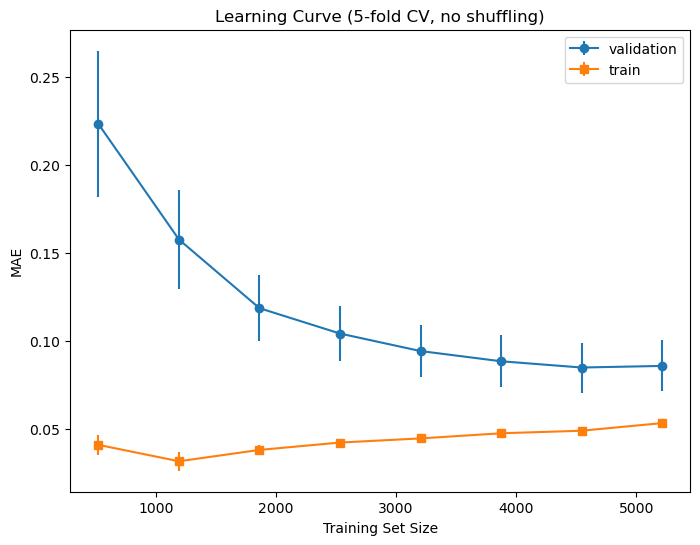

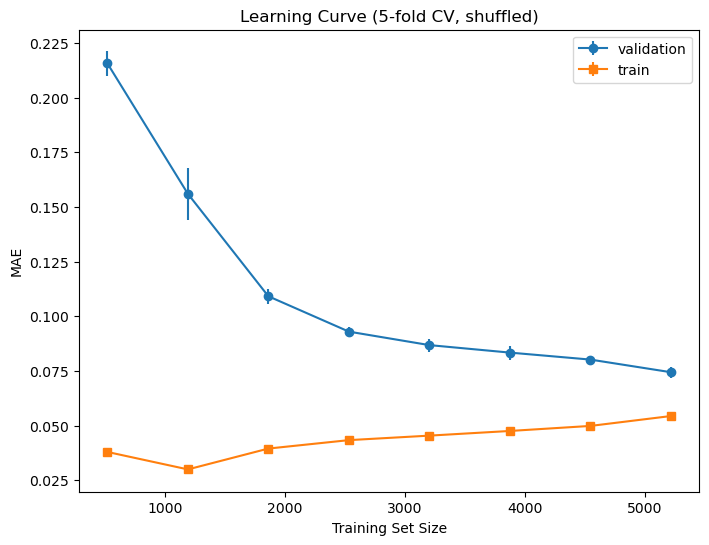

In [15]:
plot_learning_curve(sizes_1, train_mae_1, val_mae_1, title="Learning Curve (5-fold CV, no shuffling)")
plot_learning_curve(sizes_2, train_mae_2, val_mae_2, title="Learning Curve (5-fold CV, shuffled)")

In [ ]:
# My learning curves show that validation MAE reduced with dataset size and the gradient decreased, 
# which suggests to me improvements to prediction at the amount of data I have will come more from improving my features 
# instead of running more calculations.

# One thing to note is that there is a difference in the validation and training MAE even at the largest training set size,
# i.e. the model is not converging. This could be because the Magpie features I use do not fully capture the physics of the problem.
# Structural and site ordering features may be the important missing piece for the training and validation MAE to converge.
# This difference is also not 'fixable' with more data, and is a motivation for models that are more structure-aware.

In [20]:
# convert the dataframe to a numpy array for use with sklearn
X = my_df.drop(columns=non_feature_cols).values

# grab the target column, Eg, and convert it to a numpy array
y = my_df['Eg'].values

In [ ]:
# Try RF and compare to HGB. RF is a more traditional ensemble model, and is known to overfit more than HGB.
from sklearn.ensemble import RandomForestRegressor

model_RF = RandomForestRegressor(random_state=0)

In [ ]:
# Learning curve

train_sizes = np.linspace(0.1, 1.0, 8)

# 5-fold cross validation, no shuffling
sizes_1, train_scores_1, val_scores_1, fit_times_1, score_times_1 = learning_curve(model_RF, X, y, cv = cv1, 
                                                                                   scoring = "neg_mean_absolute_error",
                                                                                   train_sizes = train_sizes, return_times = True)

train_mae_1, val_mae_1 = -train_scores_1, -val_scores_1

# 5-fold cross validation, shuffled
sizes_2, train_scores_2, val_scores_2, fit_times_2, score_times_2 = learning_curve(model_RF, X, y, cv = cv2,
                                                                                   scoring = "neg_mean_absolute_error",
                                                                                   train_sizes = train_sizes, return_times = True)

train_mae_2, val_mae_2 = -train_scores_2, -val_scores_2

In [23]:
print("5-fold CV, no shuffling")
total_runtime = 0
for train_size, train_fit_time, train_score_time in zip(sizes_1, fit_times_1, train_mae_1):
    runtime = train_fit_time.sum() + train_score_time.sum()
    print(f"Train size: {train_size}, Fit time: {runtime:.1f}s")
    total_runtime += runtime
print(f"Total runtime (no shuffling): {total_runtime:.1f}s")
print()

print("5-fold CV, shuffled")
total_runtime = 0
for train_size, train_fit_time, train_score_time in zip(sizes_2, fit_times_2, train_mae_2):
    runtime = train_fit_time.sum() + train_score_time.sum()
    print(f"Train size: {train_size}, Fit time: {runtime:.1f}s")
    total_runtime += runtime
print(f"Total runtime (shuffled): {total_runtime:.1f}s")

5-fold CV, no shuffling
Train size: 521, Fit time: 9.5s
Train size: 1192, Fit time: 23.7s
Train size: 1862, Fit time: 41.4s
Train size: 2533, Fit time: 64.1s
Train size: 3203, Fit time: 77.7s
Train size: 3874, Fit time: 95.8s
Train size: 4544, Fit time: 106.0s
Train size: 5215, Fit time: 112.1s
Total runtime (no shuffling): 530.3s

5-fold CV, shuffled
Train size: 521, Fit time: 6.4s
Train size: 1192, Fit time: 18.2s
Train size: 1862, Fit time: 32.3s
Train size: 2533, Fit time: 46.5s
Train size: 3203, Fit time: 58.3s
Train size: 3874, Fit time: 72.1s
Train size: 4544, Fit time: 84.9s
Train size: 5215, Fit time: 97.8s
Total runtime (shuffled): 416.5s


In [24]:
def plot_learning_curve(sizes, train_mae, val_mae, title="Learning Curve", xlabel="Training Set Size", ylabel="MAE"):
    plt.figure(figsize=(8, 6))
    plt.errorbar(sizes, val_mae.mean(1), yerr = val_mae.std(1),
                 marker = "o", label = "validation")
    plt.errorbar(sizes, train_mae.mean(1), yerr = train_mae.std(1),
                 marker = "s", label = "train")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.legend()
    plt.show()

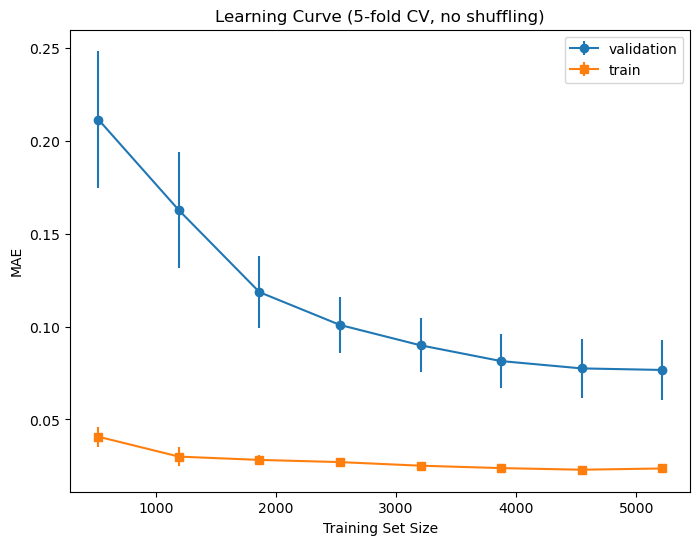

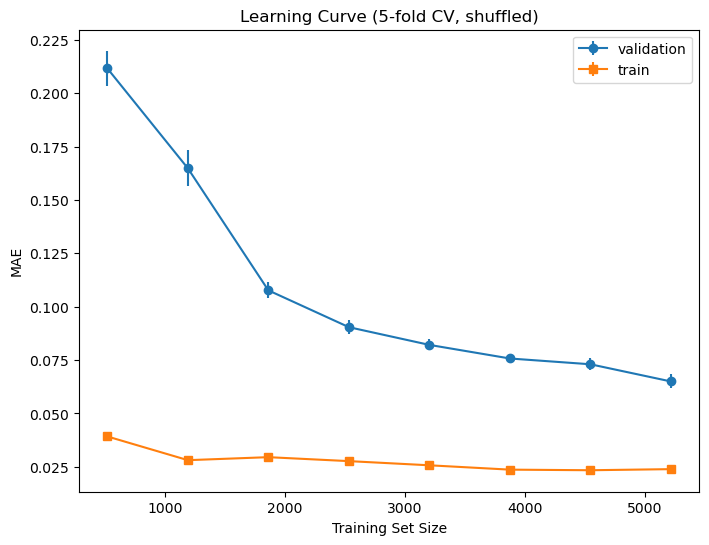

In [25]:
plot_learning_curve(sizes_1, train_mae_1, val_mae_1, title="Learning Curve (5-fold CV, no shuffling)")
plot_learning_curve(sizes_2, train_mae_2, val_mae_2, title="Learning Curve (5-fold CV, shuffled)")

In [ ]:
# Using RF, we see that there is a larger gap between training and validation MAE, which is in line with the fact that
# RF tends to overfit on training data than HGB. 
# However, it is good to note that the validation MAE of RF (~0.070) is better or comparable to HGB (~0.075), 
# which shows that the large validation-training MAE gap did not make RF a worse model.
# In fact, RF appears to be a better model than HGB at generalization.
# It should also be noted that RF's validation curve still appears to be decreasing for the shuffled CV, 
# which suggests that more data may improve the model's performance.

# RF does take ~3 times longer to train than HGB, so cost-accuracy tradeoff is a consideration when choosing between the two models.
# Though RF is more scalable with parallelization